In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Path to data folder
data_path = "../data/"

# Load core datasets
orders = pd.read_csv(os.path.join(data_path, "olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(data_path, "olist_order_items_dataset.csv"))
products = pd.read_csv(os.path.join(data_path, "olist_products_dataset.csv"))
reviews = pd.read_csv(os.path.join(data_path, "olist_order_reviews_dataset.csv"))

print("Datasets loaded successfully!")
print(f"Orders: {orders.shape[0]} rows")
print(f"Reviews: {reviews.shape[0]} rows")

Datasets loaded successfully!
Orders: 99441 rows
Reviews: 99224 rows


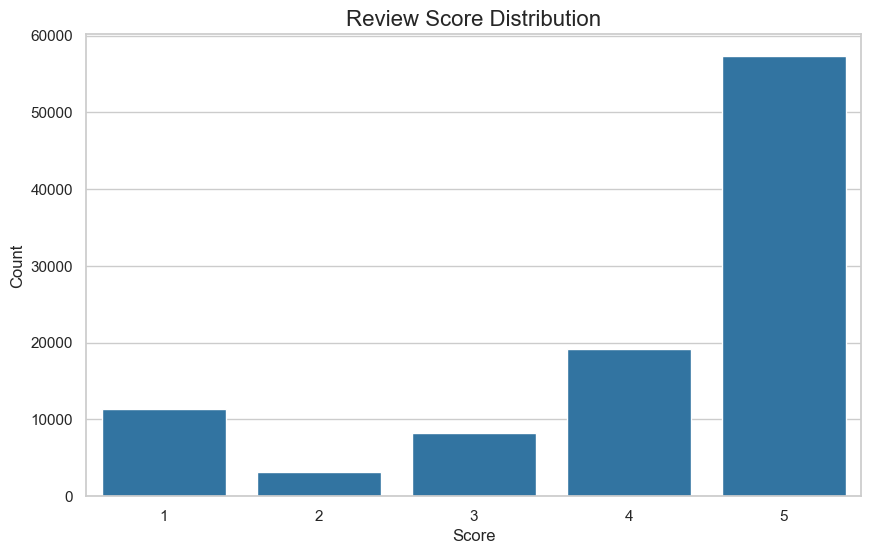

In [2]:
# Check review distribution
sns.countplot(data=reviews, x='review_score', color='#1f77b4')
plt.title('Review Score Distribution', fontsize=16)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Save visual copy to your images folder
plt.savefig('../images/output_review_score.png', bbox_inches='tight', dpi=300)
plt.show()

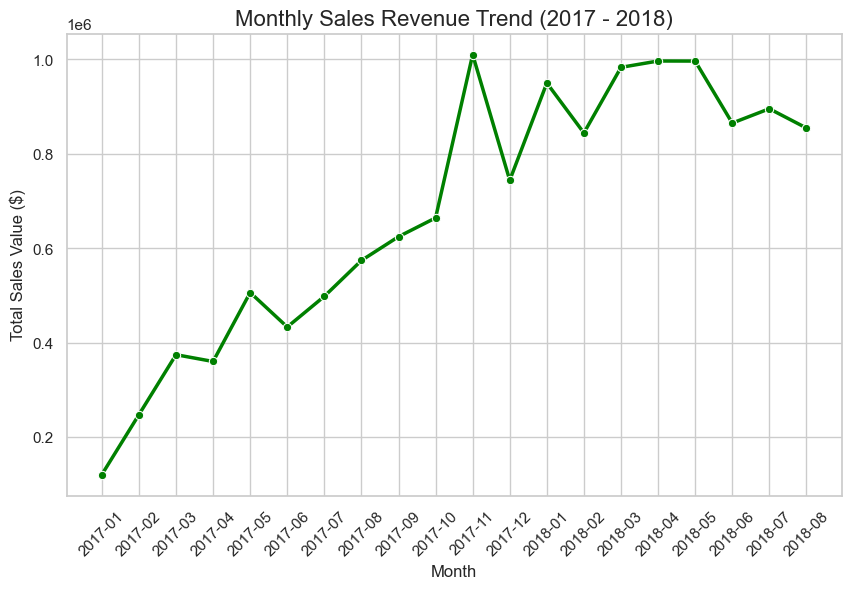

In [3]:
# Merge items and orders to align prices with timestamps
revenue_df = pd.merge(order_items, orders, on='order_id')

# Convert to datetime and isolate Year-Month format
revenue_df['order_purchase_timestamp'] = pd.to_datetime(revenue_df['order_purchase_timestamp'])
revenue_df['month_year'] = revenue_df['order_purchase_timestamp'].dt.to_period('M')

# Group and plot revenue trends
monthly_revenue = revenue_df.groupby('month_year')['price'].sum().reset_index()
monthly_revenue['month_year'] = monthly_revenue['month_year'].astype(str)

# Filter out incomplete boundary data (keep standard operational window)
monthly_revenue = monthly_revenue[(monthly_revenue['month_year'] >= '2017-01') & (monthly_revenue['month_year'] <= '2018-08')]

sns.lineplot(data=monthly_revenue, x='month_year', y='price', marker='o', color='green', linewidth=2.5)
plt.title('Monthly Sales Revenue Trend (2017 - 2018)', fontsize=16)
plt.xticks(rotation=45)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales Value ($)', fontsize=12)
plt.savefig('../images/output_monthly_revenue.png', bbox_inches='tight', dpi=300)
plt.show()

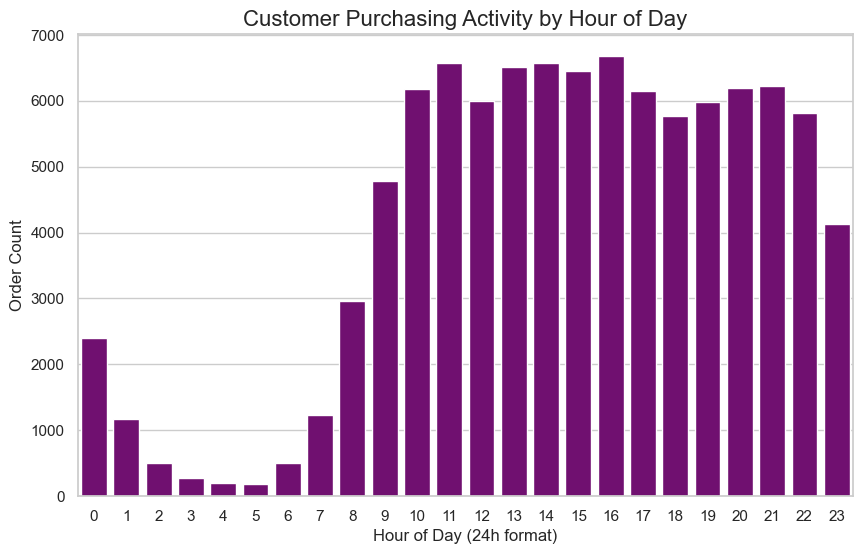

In [4]:
# Extract target hours from order timestamps
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['purchase_hour'] = orders['order_purchase_timestamp'].dt.hour

sns.countplot(data=orders, x='purchase_hour', color='purple')
plt.title('Customer Purchasing Activity by Hour of Day', fontsize=16)
plt.xlabel('Hour of Day (24h format)', fontsize=12)
plt.ylabel('Order Count', fontsize=12)
plt.savefig('../images/output_hours.png', bbox_inches='tight', dpi=300)
plt.show()

C:\Users\DELL INSPIRON\AppData\Local\Temp\ipykernel_660\920779146.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories, x='price', y='product_category_name', palette='viridis')


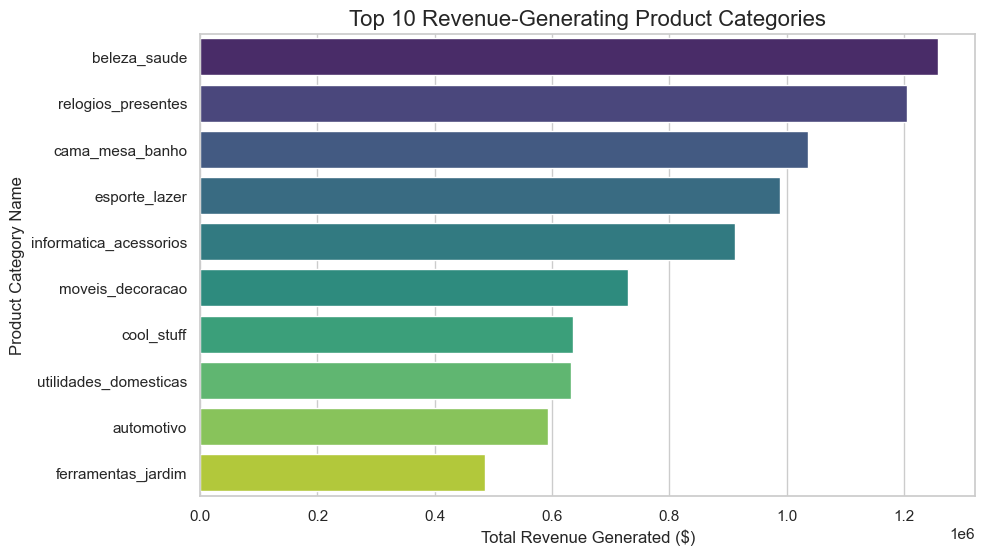

In [5]:
# Merge item pricing with product categories
product_sales = pd.merge(order_items, products, on='product_id')
top_categories = product_sales.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=top_categories, x='price', y='product_category_name', palette='viridis')
plt.title('Top 10 Revenue-Generating Product Categories', fontsize=16)
plt.xlabel('Total Revenue Generated ($)', fontsize=12)
plt.ylabel('Product Category Name', fontsize=12)
plt.savefig('../images/output_product_category.png', bbox_inches='tight', dpi=300)
plt.show()